In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("/content/solarpowergeneration.csv")
df.head()

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated
0,0.859897,69,28,7.5,0,10.0,75,8.0,29.82,0
1,0.628535,69,28,7.5,0,10.0,77,5.0,29.85,0
2,0.397172,69,28,7.5,0,10.0,70,0.0,29.89,5418
3,0.165810,69,28,7.5,0,10.0,33,0.0,29.91,25477
4,0.065553,69,28,7.5,0,10.0,21,3.0,29.89,30069


In [5]:
df.shape

(2920, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2920 entries, 0 to 2919
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   distance-to-solar-noon       2920 non-null   float64
 1   temperature                  2920 non-null   int64  
 2   wind-direction               2920 non-null   int64  
 3   wind-speed                   2920 non-null   float64
 4   sky-cover                    2920 non-null   int64  
 5   visibility                   2920 non-null   float64
 6   humidity                     2920 non-null   int64  
 7   average-wind-speed-(period)  2919 non-null   float64
 8   average-pressure-(period)    2920 non-null   float64
 9   power-generated              2920 non-null   int64  
dtypes: float64(5), int64(5)
memory usage: 228.3 KB


In [7]:
df.isnull().sum()

,0
distance-to-solar-noon,0
temperature,0
wind-direction,0
wind-speed,0
sky-cover,0
visibility,0
humidity,0
average-wind-speed-(period),1
average-pressure-(period),0
power-generated,0


In [8]:
df["average-wind-speed-(period)"] = df["average-wind-speed-(period)"].fillna(
    df["average-wind-speed-(period)"].mean()
)

In [9]:
df.isnull().sum()

,0
distance-to-solar-noon,0
temperature,0
wind-direction,0
wind-speed,0
sky-cover,0
visibility,0
humidity,0
average-wind-speed-(period),0
average-pressure-(period),0
power-generated,0


In [10]:
df.describe()

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated
count,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000,2920.000000
mean,0.503294,58.468493,24.953425,10.096986,1.987671,9.557705,73.513699,10.129154,30.017760,6979.846233
std,0.298024,6.841200,6.915178,4.838185,1.411978,1.383884,15.077139,7.260303,0.142006,10312.336413
min,0.050401,42.000000,1.000000,1.100000,0.000000,0.000000,14.000000,0.000000,29.480000,0.000000
25%,0.243714,53.000000,25.000000,6.600000,1.000000,10.000000,65.000000,5.000000,29.920000,0.000000
50%,0.478957,59.000000,27.000000,10.000000,2.000000,10.000000,77.000000,9.000000,30.000000,404.000000
75%,0.739528,63.000000,29.000000,13.100000,3.000000,10.000000,84.000000,15.000000,30.110000,12723.500000
max,1.141361,78.000000,36.000000,26.600000,4.000000,10.000000,100.000000,40.000000,30.530000,36580.000000


In [11]:
df['power-generated'].describe()


,power-generated
count,2920.000000
mean,6979.846233
std,10312.336413
min,0.000000
25%,0.000000
50%,404.000000
75%,12723.500000
max,36580.000000


In [12]:
df.columns

Index(['distance-to-solar-noon', 'temperature', 'wind-direction', 'wind-speed',
       'sky-cover', 'visibility', 'humidity', 'average-wind-speed-(period)',
       'average-pressure-(period)', 'power-generated'],
      dtype='object')

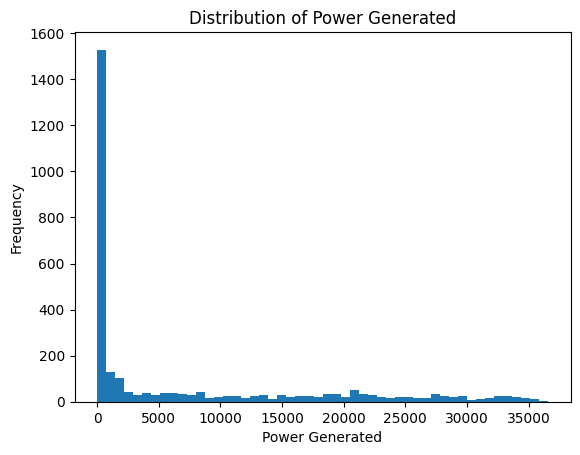

In [13]:
plt.hist(df["power-generated"], bins = 50)
plt.xlabel("Power Generated")
plt.ylabel("Frequency")
plt.title("Distribution of Power Generated")
plt.show()

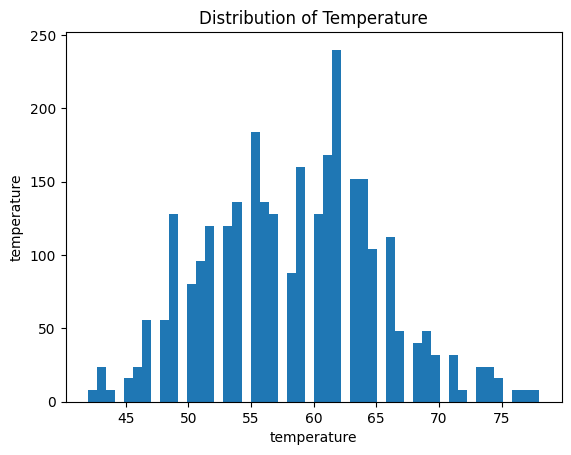

In [14]:
plt.hist(df["temperature"], bins = 50)
plt.xlabel("temperature")
plt.ylabel("temperature")
plt.title("Distribution of Temperature")
plt.show()

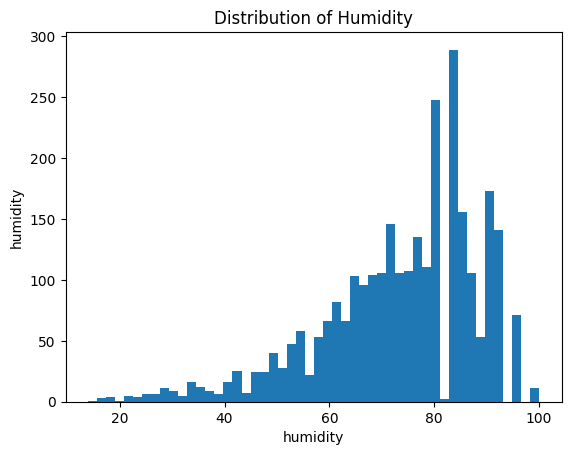

In [15]:
plt.hist(df["humidity"], bins = 50)
plt.xlabel("humidity")
plt.ylabel("humidity")
plt.title("Distribution of Humidity")
plt.show()

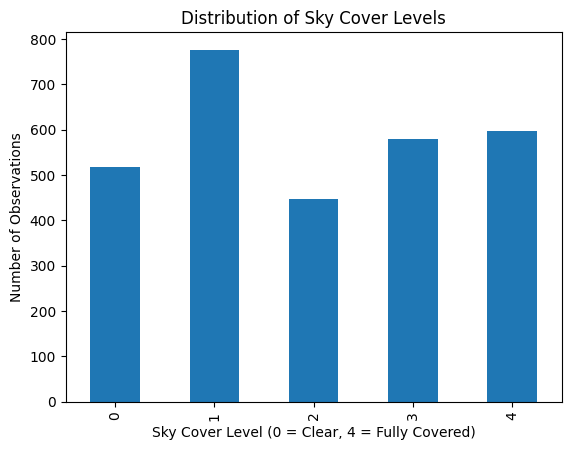

In [16]:
df["sky-cover"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Sky Cover Level (0 = Clear, 4 = Fully Covered)")
plt.ylabel("Number of Observations")
plt.title("Distribution of Sky Cover Levels")
plt.show()

# Levels:
# 0 → completely clear
# 1 → slightly covered
# 2 → moderately covered
# 3 → heavily covered
# 4 → fully covered


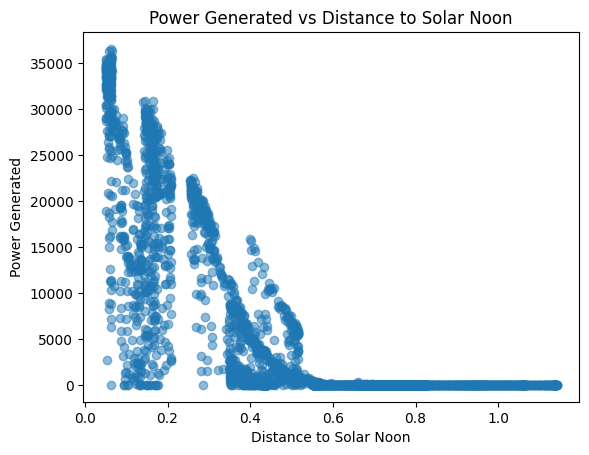

In [17]:
plt.scatter(df["distance-to-solar-noon"], df["power-generated"], alpha=0.5)
plt.xlabel("Distance to Solar Noon")
plt.ylabel("Power Generated")
plt.title("Power Generated vs Distance to Solar Noon")
plt.show()


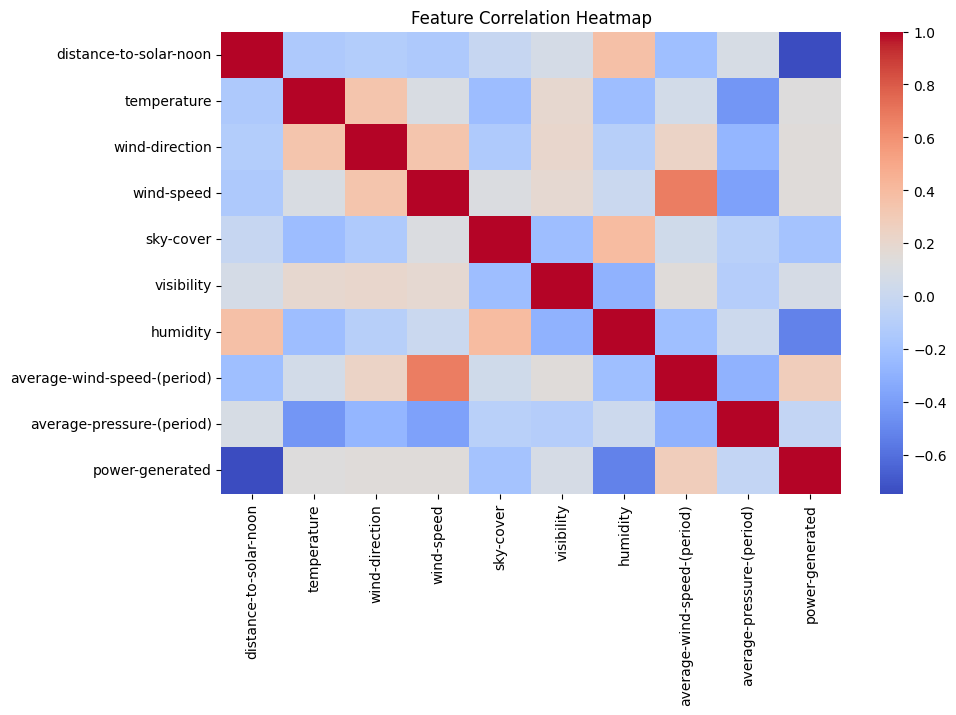

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


Model Building


In [19]:
# Define target
y = df["power-generated"]

# Define features (drop target column)
X = df.drop("power-generated", axis=1)

X.head()


,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period)
0,0.859897,69,28,7.5,0,10.0,75,8.0,29.82
1,0.628535,69,28,7.5,0,10.0,77,5.0,29.85
2,0.397172,69,28,7.5,0,10.0,70,0.0,29.89
3,0.165810,69,28,7.5,0,10.0,33,0.0,29.91
4,0.065553,69,28,7.5,0,10.0,21,3.0,29.89


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)


Training samples: (2336, 9)
Testing samples: (584, 9)


In [21]:
from sklearn.linear_model import LinearRegression

# Initialize model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)


LinearRegression()

In [22]:
y_pred = model.predict(X_test)


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE: 4981.201479686538
RMSE: 6284.51879812755
R2 Score: 0.6250592396092093


In [24]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2:", r2_rf)


Random Forest MAE: 1548.2990582191778
Random Forest RMSE: 3407.4542406310743
Random Forest R2: 0.8897753670719873


In [25]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree MAE:", mae_dt)
print("Decision Tree RMSE:", rmse_dt)
print("Decision Tree R2:", r2_dt)


Decision Tree MAE: 1999.2568493150684
Decision Tree RMSE: 4439.850798508177
Decision Tree R2: 0.8128648591958793


In [26]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=42)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting MAE:", mae_gb)
print("Gradient Boosting RMSE:", rmse_gb)
print("Gradient Boosting R2:", r2_gb)


Gradient Boosting MAE: 1677.6536437473296
Gradient Boosting RMSE: 3228.960394008769
Gradient Boosting R2: 0.9010207787205786


In [27]:
# Training performance
y_train_pred_gb = gb_model.predict(X_train)

r2_train_gb = r2_score(y_train, y_train_pred_gb)
r2_test_gb = r2_score(y_test, y_pred_gb)

print("Training R2:", r2_train_gb)
print("Testing R2:", r2_test_gb)


Training R2: 0.9453990791657144
Testing R2: 0.9010207787205786


In [28]:
import pandas as pd

feature_importance = pd.Series(
    gb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance


,0
distance-to-solar-noon,0.845677
sky-cover,0.075139
humidity,0.048418
wind-direction,0.015780
wind-speed,0.007263
average-pressure-(period),0.002828
average-wind-speed-(period),0.002426
temperature,0.002247
visibility,0.000222


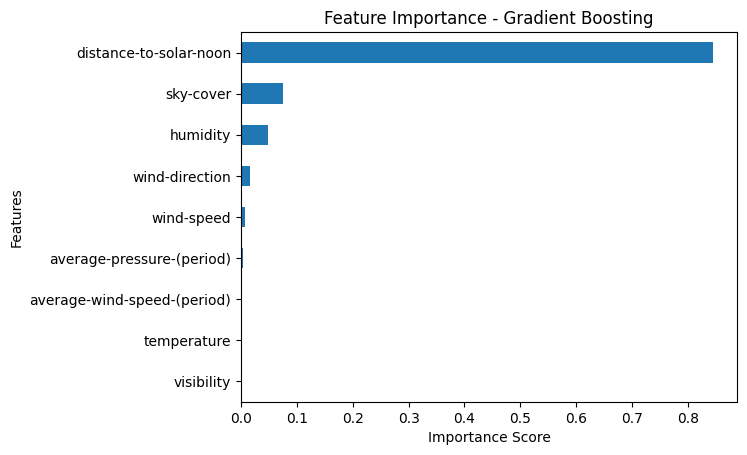

In [29]:
import matplotlib.pyplot as plt

feature_importance.sort_values(ascending=True).plot(kind='barh')

plt.title("Feature Importance - Gradient Boosting")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [30]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        mae,
        mae_dt,
        mae_rf,
        mae_gb
    ],
    "RMSE": [
        rmse,
        rmse_dt,
        rmse_rf,
        rmse_gb
    ],
    "R2 Score": [
        r2,
        r2_dt,
        r2_rf,
        r2_gb
    ]
})

model_comparison


,Model,MAE,RMSE,R2 Score
0,Linear Regression,4981.201480,6284.518798,0.625059
1,Decision Tree,1999.256849,4439.850799,0.812865
2,Random Forest,1548.299058,3407.454241,0.889775
3,Gradient Boosting,1677.653644,3228.960394,0.901021


In [31]:
model_comparison.sort_values(by="R2 Score", ascending=False)


,Model,MAE,RMSE,R2 Score
3,Gradient Boosting,1677.653644,3228.960394,0.901021
2,Random Forest,1548.299058,3407.454241,0.889775
1,Decision Tree,1999.256849,4439.850799,0.812865
0,Linear Regression,4981.201480,6284.518798,0.625059


Model Deployment


In [32]:
import joblib

joblib.dump(gb_model, "solar_power_model.pkl")

['solar_power_model.pkl']

In [33]:

loaded_model = joblib.load("solar_power_model.pkl")

In [34]:
sample_input = X_test.iloc[[0]]

prediction = loaded_model.predict(sample_input)

print("Predicted Power:", prediction[0])
print("Actual Power:", y_test.iloc[0])

Predicted Power: 21343.759848656988
Actual Power: 21804


In [35]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 68.6 MB/s eta 0:00:00
  Attempting uninstall: cachetools
    Found existing installation: cachetools 7.0.1
    Uninstalling cachetools-7.0.1:
      Successfully uninstalled cachetools-7.0.1


In [36]:
from pyngrok import ngrok

ngrok.set_auth_token("36H7wZAtOuunrHIFpJV22o2RnXP_joVGhykmiu4z3uVdoGgz")

In [37]:
%%writefile app.py

import streamlit as st
import joblib
import numpy as np

# Load model
model = joblib.load("solar_power_model.pkl")

st.title("Solar Power Generation Prediction")

st.write("Enter environmental values:")

distance = st.number_input("Distance to Solar Noon (radians)", value=0.1)
temperature = st.number_input("Temperature", value=25.0)
wind_direction = st.number_input("Wind Direction", value=180.0)
wind_speed = st.number_input("Wind Speed", value=5.0)
sky_cover = st.slider("Sky Cover (0-4)", 0, 4, 1)
visibility = st.number_input("Visibility", value=10.0)
humidity = st.number_input("Humidity", value=50.0)
avg_wind_speed = st.number_input("Average Wind Speed", value=5.0)
avg_pressure = st.number_input("Average Pressure", value=29.9)

if st.button("Predict"):
    input_data = np.array([[distance, temperature, wind_direction,
                            wind_speed, sky_cover, visibility,
                            humidity, avg_wind_speed, avg_pressure]])

    prediction = model.predict(input_data)

    st.success(f"Predicted Power: {prediction[0]:.2f} Joules")

Writing app.py


In [38]:
!streamlit run app.py &>/content/logs.txt &

In [39]:
#ngrok.kill()

In [40]:
public_url = ngrok.connect(8501)
public_url

<NgrokTunnel: "https://uninimical-unfleeced-felipe.ngrok-free.dev" -> "http://localhost:8501">